In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
employees = pd.DataFrame({
    "EmpID": [101,102,103,104,105,106,107,108],
    "EmpName": ["Amit","Ravi","Neha","Pooja","Karan","Sneha","Vikas","Anjali"],
    "Department": ["IT","HR","IT","Finance","HR","Finance","IT","HR"],
    "Location": ["BLR","MUM","BLR","DEL","MUM","DEL","BLR","MUM"],
    "Salary": [60000,90000,75000,65000,50000,95000,85000,52000]
})
employees

,EmpID,EmpName,Department,Location,Salary
0,101,Amit,IT,BLR,60000
1,102,Ravi,HR,MUM,90000
2,103,Neha,IT,BLR,75000
3,104,Pooja,Finance,DEL,65000
4,105,Karan,HR,MUM,50000
5,106,Sneha,Finance,DEL,95000
6,107,Vikas,IT,BLR,85000
7,108,Anjali,HR,MUM,52000


In [3]:
audit = pd.DataFrame({
    "EmpID": [101,102,103,104,105,106,107,108],
    "Audit_Type": ["Internal","Internal","External","Internal","External","External","Internal","External"],
    "Audit_Score": [85,78,92,88,70,95,80,75],
    "Compliance_Status": ["Pass","Pass","Pass","Pass","Fail","Pass","Pass","Fail"],
    "Audit_Month": ["Jan","Jan","Feb","Feb","Mar","Mar","Jan","Feb"]
})
audit

,EmpID,Audit_Type,Audit_Score,Compliance_Status,Audit_Month
0,101,Internal,85,Pass,Jan
1,102,Internal,78,Pass,Jan
2,103,External,92,Pass,Feb
3,104,Internal,88,Pass,Feb
4,105,External,70,Fail,Mar
5,106,External,95,Pass,Mar
6,107,Internal,80,Pass,Jan
7,108,External,75,Fail,Feb


In [4]:
# Q1. Combine employee and audit data

combined_data = employees.merge(audit,on="EmpID",how="left")
combined_data

,EmpID,EmpName,Department,Location,Salary,Audit_Type,Audit_Score,Compliance_Status,Audit_Month
0,101,Amit,IT,BLR,60000,Internal,85,Pass,Jan
1,102,Ravi,HR,MUM,90000,Internal,78,Pass,Jan
2,103,Neha,IT,BLR,75000,External,92,Pass,Feb
3,104,Pooja,Finance,DEL,65000,Internal,88,Pass,Feb
4,105,Karan,HR,MUM,50000,External,70,Fail,Mar
5,106,Sneha,Finance,DEL,95000,External,95,Pass,Mar
6,107,Vikas,IT,BLR,85000,Internal,80,Pass,Jan
7,108,Anjali,HR,MUM,52000,External,75,Fail,Feb


In [14]:
# QUESTION 2 — Average Audit Score by Department

combined_data.groupby("Department")["Audit_Score"].mean().round(2).sort_values(ascending=False)

Department
Finance    91.50
IT         85.67
HR         74.33
Name: Audit_Score, dtype: float64

In [15]:
# QUESTION 3 — Department × Audit Type (Pivot logic)

combined_data.groupby(["Department","Audit_Type"])["Audit_Score"].mean().unstack(fill_value=0)

Audit_Type,External,Internal
Department,,
Finance,95.0,88.0
HR,72.5,78.0
IT,92.0,82.5


In [16]:
# QUESTION 4 — Count of Audits per Month

combined_data.groupby("Audit_Month").size()

Audit_Month
Feb    3
Jan    3
Mar    2
dtype: int64

In [18]:
# QUESTION 5 — Compliance Pass vs Fail (Counts)

combined_data["Compliance_Status"].value_counts()

Compliance_Status
Pass    6
Fail    2
Name: count, dtype: int64

In [31]:
# QUESTION 6 — Compliance % by Department

#combined_data
comp = combined_data.groupby(["Department","Compliance_Status"]).size().unstack(fill_value=0)
comp["percentage"] = comp["Pass"]/ comp.sum(axis=1)*100
comp

Compliance_Status,Fail,Pass,percentage
Department,,,
Finance,0,2,100.000000
HR,2,1,33.333333
IT,0,3,100.000000


In [35]:
# QUESTION 7 — High Salary but Failed Audit

combined_data[combined_data["Compliance_Status"] == "Fail"].sort_values("Salary",ascending= False)

,EmpID,EmpName,Department,Location,Salary,Audit_Type,Audit_Score,Compliance_Status,Audit_Month
7,108,Anjali,HR,MUM,52000,External,75,Fail,Feb
4,105,Karan,HR,MUM,50000,External,70,Fail,Mar


In [39]:
# QUESTION 8 — Identify High-Risk Employees (Rule-based)Definition:External audit, Score < 80, Compliance = Fail

combined_data[
    (combined_data["Audit_Type"] == "External") &
    (combined_data["Audit_Score"] < 80) &
    (combined_data["Compliance_Status"] == "Fail")
]

,EmpID,EmpName,Department,Location,Salary,Audit_Type,Audit_Score,Compliance_Status,Audit_Month
4,105,Karan,HR,MUM,50000,External,70,Fail,Mar
7,108,Anjali,HR,MUM,52000,External,75,Fail,Feb


<Axes: xlabel='Department'>

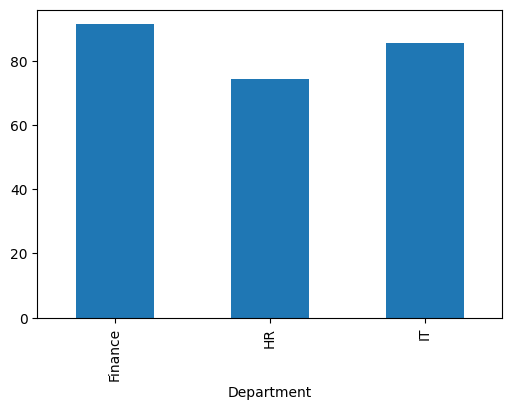

In [45]:
# QUESTION 9 - Audit score by dept visual

combined_data.groupby("Department")["Audit_Score"].mean().plot(kind="bar",figsize=(6,4))

In [50]:
combined_data.groupby("Audit_Month")["Audit_Score"].mean()

Audit_Month
Feb    85.0
Jan    81.0
Mar    82.5
Name: Audit_Score, dtype: float64